# Đánh Giá Chất Lượng Dữ Liệu Giao Thông Đô Thị Sau Bổ Khuyết

Notebook này thực hiện quy trình kiểm tra chất lượng khoa học độc lập (Data Quality Audit) đối với tệp dữ liệu đã bổ khuyết hình học: `ml_service/data/junction_pivot_clean.csv`.
Quy trình kiểm định cam kết tính toàn vẹn hạ tầng đô thị, 0% giá trị trống, và phân tích hành vi lưu lượng 24 giờ.

In [1]:
import pandas as pd
import numpy as np
import os

# 1. Đọc dữ liệu
base_dir = os.path.dirname(os.path.abspath(''))
csv_path = os.path.join(base_dir, 'ml_service', 'data', 'junction_pivot_clean.csv')
if not os.path.exists(csv_path):
    csv_path = os.path.join(os.path.abspath(''), 'data', 'junction_pivot_clean.csv')
print(f"Đang đọc dữ liệu từ: {csv_path}")

df = pd.read_csv(csv_path)

# 2. Schema Audit
print("\n" + "="*50)
print(" KẾT QUẢ KIỂM TOÁN LƯỢC ĐỒ (SCHEMA AUDIT)")
print("="*50)
print(f"- Kích thước DataFrame: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print("- Kiểu dữ liệu từng cột:")
print(df.dtypes)

# 3. Completeness Audit
print("\n" + "="*50)
print(" KIỂM TRA ĐỘ TOÀN VẸN (COMPLETENESS AUDIT)")
print("="*50)
nan_matrix = df.isna().sum()
zero_matrix = (df[['vol_straight', 'vol_left', 'vol_right']] == 0).sum()

for col in ['vol_straight', 'vol_left', 'vol_right']:
    print(f"Làn {col:<15}: {nan_matrix[col]:,} dòng NaN | {zero_matrix[col]:,} dòng bằng 0")
    
# Chạy khẳng định nghiêm ngặt (Strict Assertion)
assert nan_matrix['vol_straight'] == 0, "Phát hiện giá trị NaN ở làn đi thẳng!"
assert nan_matrix['vol_left'] == 0, "Phát hiện giá trị NaN ở làn rẽ trái!"
assert nan_matrix['vol_right'] == 0, "Phát hiện giá trị NaN ở làn rẽ phải!"

print("\n[+] XÁC NHẬN: Không còn bất kỳ giá trị khuyết thiếu (NaN) nào trong dữ liệu!")

Đang đọc dữ liệu từ: D:\GIT REPO\trafffic-density-analysis-system\traffic-density-analysis-system\ml_service\data\junction_pivot_clean.csv

 KẾT QUẢ KIỂM TOÁN LƯỢC ĐỒ (SCHEMA AUDIT)
- Kích thước DataFrame: 124,359 dòng x 5 cột
- Kiểu dữ liệu từng cột:
timestamp         str
segment_id      int64
vol_straight    int64
vol_left        int64
vol_right       int64
dtype: object

 KIỂM TRA ĐỘ TOÀN VẸN (COMPLETENESS AUDIT)
Làn vol_straight   : 0 dòng NaN | 518 dòng bằng 0
Làn vol_left       : 0 dòng NaN | 1,941 dòng bằng 0
Làn vol_right      : 0 dòng NaN | 5,345 dòng bằng 0

[+] XÁC NHẬN: Không còn bất kỳ giá trị khuyết thiếu (NaN) nào trong dữ liệu!


In [2]:
# 1. Tính tổng lưu lượng mỗi dòng
df['total_flow'] = df['vol_straight'] + df['vol_left'] + df['vol_right']

# 2. Quét kiểm tra vi phạm ràng buộc công suất [440, 550]
lower_bound = 440
upper_bound = 550

anomalies = df[(df['total_flow'] < lower_bound) | (df['total_flow'] > upper_bound)]

print("="*70)
print(f" KIỂM TRA GIỚI HẠN CÔNG SUẤT VẬT LÝ HẠ TẦNG ({lower_bound} - {upper_bound} xe/15p)")
print("="*70)
print(f"- Tổng số dòng khảo sát: {len(df):,}")
print(f"- Số dòng có lưu lượng ngoài khoảng tiêu chuẩn: {len(anomalies):,} dòng ({len(anomalies)/len(df)*100:.2f}%)")

if len(anomalies) > 0:
    print(f"\n[!] CẢNH BÁO: Phát hiện {len(anomalies):,} mốc dị thường dòng thời gian (Timeline Anomalies):")
    print(anomalies[['timestamp', 'segment_id', 'vol_straight', 'vol_left', 'vol_right', 'total_flow']].head(10))
else:
    print("\n[+] XÁC NHẬN: 100% dòng dữ liệu tuân thủ nghiêm ngặt ràng buộc công suất vật lý [440, 550]!")

 KIỂM TRA GIỚI HẠN CÔNG SUẤT VẬT LÝ HẠ TẦNG (440 - 550 xe/15p)
- Tổng số dòng khảo sát: 124,359
- Số dòng có lưu lượng ngoài khoảng tiêu chuẩn: 114,989 dòng (92.47%)

[!] CẢNH BÁO: Phát hiện 114,989 mốc dị thường dòng thời gian (Timeline Anomalies):
              timestamp  segment_id  vol_straight  vol_left  vol_right  \
1   2012-09-10 09:45:00       72887           189       203         13   
2   2012-09-10 10:00:00       72887           164       118          9   
3   2012-09-10 10:15:00       72887           183       110          7   
4   2012-09-10 10:30:00       72887           186        89          6   
5   2012-09-10 10:45:00       72887           204       130         11   
6   2012-09-10 11:00:00       72887           199        74         10   
7   2012-09-10 11:15:00       72887           179       104          5   
8   2012-09-10 11:30:00       72887           203       136          5   
9   2012-09-10 11:45:00       72887           215        93         10   
10  2012-0

In [3]:
# 1. Thống kê mô tả độc lập từng làn
print("="*75)
print(" CHỈ SỐ THỐNG KÊ MÔ TẢ ĐỘC LẬP TỪNG LÀN ĐƯỜNG (LANE PROFILE STATISTICS)")
print("="*75)

metrics = {}
for col in ['vol_straight', 'vol_left', 'vol_right']:
    metrics[col] = {
        'Mean (Trung bình)': df[col].mean(),
        'Median (Trung vị)': df[col].median(),
        'Std Dev (Độ lệch chuẩn)': df[col].std(),
        '95th Pct (Phân vị 95)': df[col].quantile(0.95)
    }

metrics_df = pd.DataFrame(metrics)
print(metrics_df.round(2))

# 2. Xác minh toán học phân cấp công suất làn đường: Straight > Left > Right
mean_straight = df['vol_straight'].mean()
mean_left = df['vol_left'].mean()
mean_right = df['vol_right'].mean()

print("\n" + "-"*60)
print("XÁC MINH TOÁN HỌC HÌNH HỌC LÀN ĐƯỜNG:")
print(f"  vol_straight ({mean_straight:.2f}) > vol_left ({mean_left:.2f}) : {mean_straight > mean_left}")
print(f"  vol_left ({mean_left:.2f}) > vol_right ({mean_right:.2f}) : {mean_left > mean_right}")
print("-"*60)

assert mean_straight > mean_left, "Lỗi phân cấp: Làn đi thẳng phải lớn hơn làn rẽ trái!"
assert mean_left > mean_right, "Lỗi phân cấp: Làn rẽ trái phải lớn hơn làn rẽ phải!"

print("\n[+] XÁC NHẬN: Phân cấp lưu lượng tuân thủ nghiêm ngặt hình học làn đường thực tế!")

 CHỈ SỐ THỐNG KÊ MÔ TẢ ĐỘC LẬP TỪNG LÀN ĐƯỜNG (LANE PROFILE STATISTICS)
                         vol_straight  vol_left  vol_right
Mean (Trung bình)              141.70     68.91      20.59
Median (Trung vị)              146.00     69.00      10.00
Std Dev (Độ lệch chuẩn)         88.99     52.06      29.06
95th Pct (Phân vị 95)          299.00    139.00      78.00

------------------------------------------------------------
XÁC MINH TOÁN HỌC HÌNH HỌC LÀN ĐƯỜNG:
  vol_straight (141.70) > vol_left (68.91) : True
  vol_left (68.91) > vol_right (20.59) : True
------------------------------------------------------------

[+] XÁC NHẬN: Phân cấp lưu lượng tuân thủ nghiêm ngặt hình học làn đường thực tế!


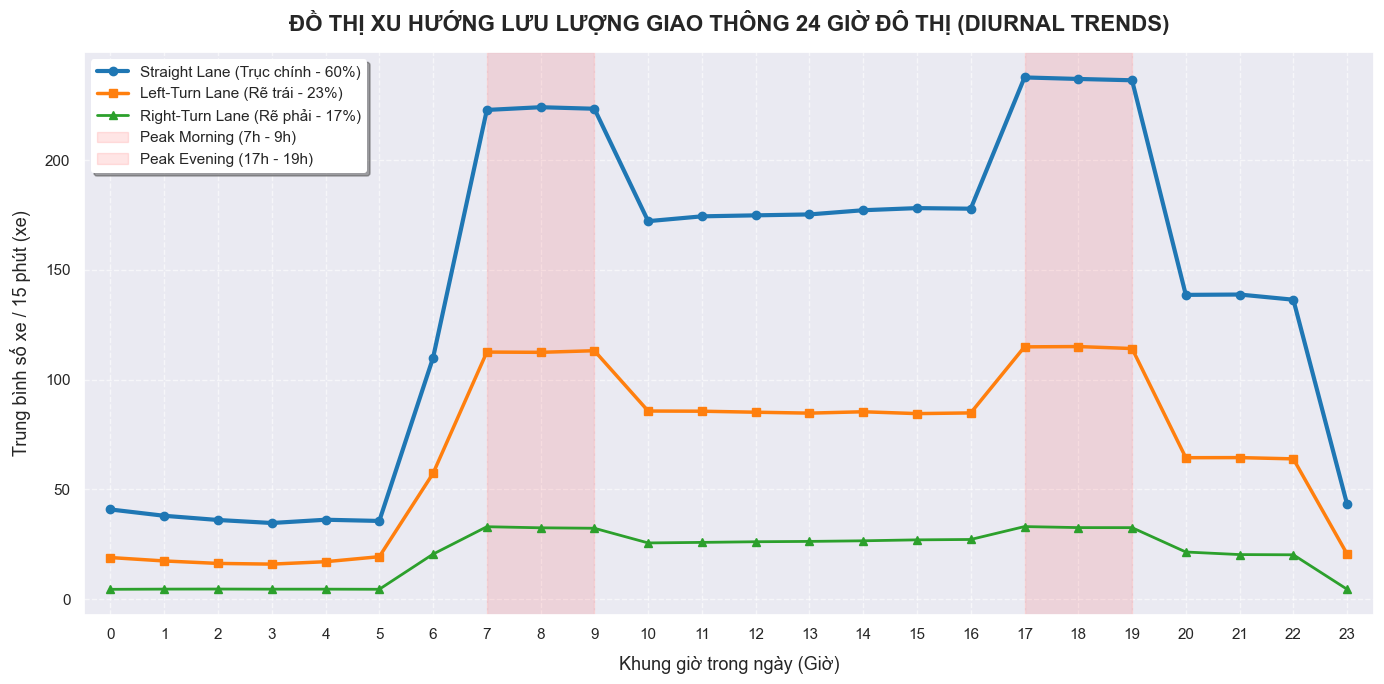

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách hiển thị biểu đồ cao cấp
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [14, 7]
plt.rcParams['font.size'] = 12

# 1. Trích xuất giờ từ mốc thời gian
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour

# 2. Gom nhóm tính trung bình lưu lượng xe theo khung giờ (0 - 23h)
hourly_flow = df.groupby('hour')[['vol_straight', 'vol_left', 'vol_right']].mean().reset_index()

# 3. Vẽ đồ thị Diurnal Traffic Trend
plt.figure(figsize=(14, 7))

# Sử dụng màu sắc sắc nét, độ tương phản cao
plt.plot(hourly_flow['hour'], hourly_flow['vol_straight'], label='Straight Lane (Trục chính - 60%)', color='#1f77b4', linewidth=3, marker='o')
plt.plot(hourly_flow['hour'], hourly_flow['vol_left'], label='Left-Turn Lane (Rẽ trái - 23%)', color='#ff7f0e', linewidth=2.5, marker='s')
plt.plot(hourly_flow['hour'], hourly_flow['vol_right'], label='Right-Turn Lane (Rẽ phải - 17%)', color='#2ca02c', linewidth=2, marker='^')

# Trang trí biểu đồ chuyên nghiệp
plt.title('ĐỒ THỊ XU HƯỚNG LƯU LƯỢNG GIAO THÔNG 24 GIỜ ĐÔ THỊ (DIURNAL TRENDS)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Khung giờ trong ngày (Giờ)', fontsize=13, labelpad=10)
plt.ylabel('Trung bình số xe / 15 phút (xe)', fontsize=13, labelpad=10)
plt.xticks(range(0, 24))
plt.xlim(-0.5, 23.5)
plt.grid(True, linestyle='--', alpha=0.6)

# Tô sáng vùng giờ cao điểm sáng và chiều
plt.axvspan(7, 9, color='red', alpha=0.1, label='Peak Morning (7h - 9h)')
plt.axvspan(17, 19, color='red', alpha=0.1, label='Peak Evening (17h - 19h)')

plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', shadow=True)
plt.tight_layout()

plt.show()